# Who is the best footballer of the last 25 years?

Most arguments about the greatest player are not really disagreements about
facts. They are disagreements about **what the question means**, conducted as
though they were about facts. One person means peak. Another means longevity. A
third means trophies. Nobody says which, so nobody can be wrong, and nobody ever
moves.

I wanted to take a different route. Instead of arguing about the answer, I wrote
down **what greatness requires**, eleven things a player must have, and then
asked who has all of them.

By this definition, a player who fails any single requirement is not the best.
And I publish which requirement they failed, so you can argue with the
definition instead of just taking my word for it.

In [1]:
import warnings

import matplotlib
import pandas as pd

from gambeta import needs, tifo

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.figsize"] = (10, 5.5)

SAMPLE = "../data/sample"
ranking = pd.read_parquet(f"{SAMPLE}/ranking.parquet")
seasons = pd.read_parquet(f"{SAMPLE}/player_season_scored.parquet")
offsets = pd.read_parquet(f"{SAMPLE}/league_offsets.parquet")
keepers = pd.read_parquet(f"{SAMPLE}/keeper_ranking.parquet")

first = tifo.season_label(seasons["season"].min())
last = tifo.season_label(seasons["season"].max())

print(f"{len(ranking):,} players ranked")
print(f"{len(seasons):,} player-seasons")
print(f"leagues: {', '.join(sorted(seasons['league'].unique()))}")
print(f"seasons: {first} to {last}")

5,508 players ranked
39,877 player-seasons
leagues: ENG-Premier League, ESP-La Liga, FRA-Ligue 1, GER-Bundesliga, ITA-Serie A
seasons: 2000-01 to 2024-25


## The eleven requirements

Each one is measured across every season and every league, then pooled per
player and weighted by minutes. All of them are oriented so that **higher is
better**, including discipline, which gets negated at source. That way a clean
player scores above a dirty one and no code downstream has to remember which
direction any particular metric runs in.

In [2]:
pd.DataFrame(
    [
        {"#": i + 1, "requirement": r.label, "key": r.key, "grain": r.kind}
        for i, r in enumerate(needs.OUTFIELD)
    ]
).set_index("#")

,requirement,key,grain
#,,,
1,Scores goals,scoring,season
2,Creates goals,creation,season
3,Finishes clinically,finishing,season
4,Generates threat,threat,season
5,Carries his team,team_share,season
6,Beats his team's level,above_team,season
7,Is available,availability,season
8,Is picked to start,reliability,season
9,Sustains it,longevity,career


## Gate first, then rank

I read "must have" literally. A player has to clear the 40th percentile on **all
eleven** requirements to qualify at all. Only then do the qualifiers get ranked.

A weighted average on its own would let a player be genuinely poor at something
my own list calls mandatory and still win on volume elsewhere. The gate is what
stops that from happening.

In [3]:
qualified = ranking[ranking["qualified"]]
print(
    f"{len(qualified)} of {len(ranking):,} players clear all eleven requirements "
    f"({100 * len(qualified) / len(ranking):.1f}%)"
)

qualified.head(15)[["player", "score", "seasons", "leagues"]].round(2)

345 of 5,508 players clear all eleven requirements (6.3%)


,player,score,seasons,leagues
0,Lionel Messi,3.32,18,"ESP-La Liga, FRA-Ligue 1"
1,Cristiano Ronaldo,2.93,19,"ENG-Premier League, ESP-La Liga, ITA-Serie A"
2,Kylian Mbappé,2.75,9,"ESP-La Liga, FRA-Ligue 1"
3,Erling Haaland,2.72,6,"ENG-Premier League, GER-Bundesliga"
4,Harry Kane,2.68,11,"ENG-Premier League, GER-Bundesliga"
5,Thierry Henry,2.64,10,"ENG-Premier League, ESP-La Liga"
6,Luis Suárez,2.59,12,"ENG-Premier League, ESP-La Liga"
7,Robert Lewandowski,2.57,15,"ESP-La Liga, GER-Bundesliga"
8,Mohamed Salah,2.52,11,"ENG-Premier League, ITA-Serie A"
9,Karim Benzema,2.35,17,"ESP-La Liga, FRA-Ligue 1"


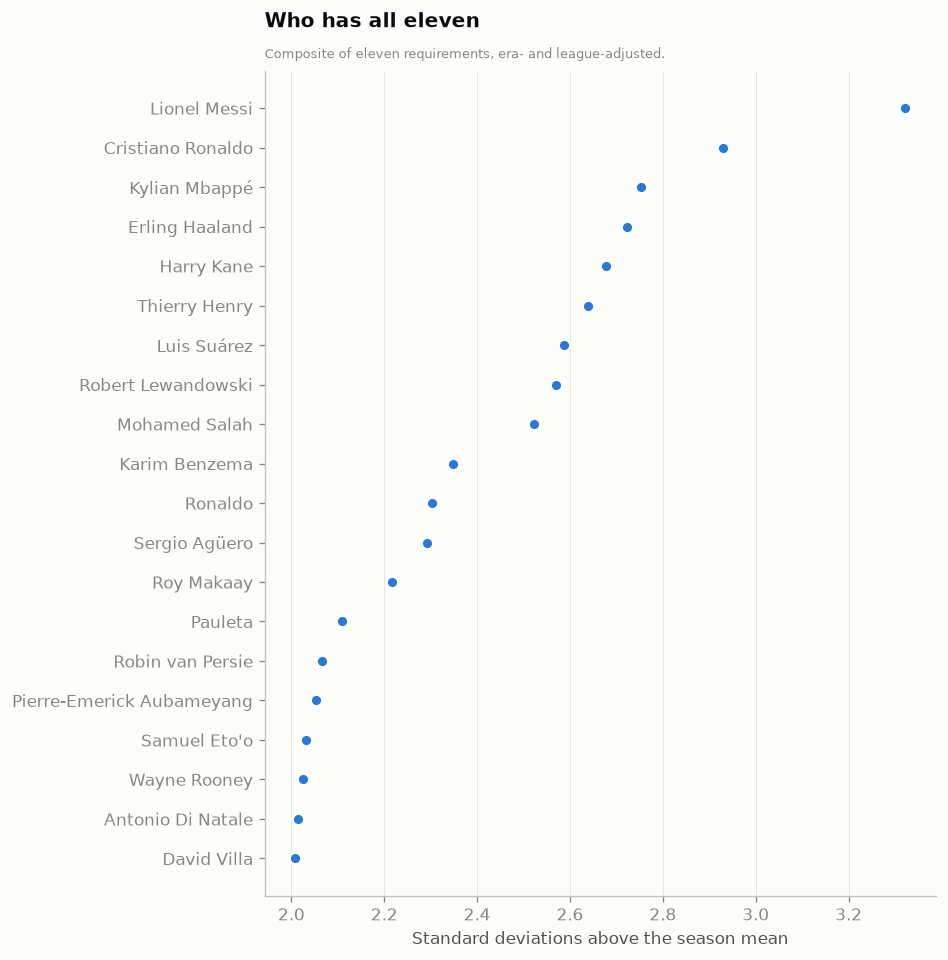

In [4]:
fig = tifo.ranked_dots(
    qualified.assign(lo=qualified["score"], hi=qualified["score"]),
    top=20,
    title="Who has all eleven",
    subtitle="Composite of eleven requirements, era- and league-adjusted.",
)

## A career is not league-bound

Look at the `leagues` column. Ronaldo's career is England, Spain and Italy:
nineteen seasons pooled into one player, not three separate league careers.

This is the single most important structural decision in the whole project.
Ranking "the best player in a league" answers a different and much less
interesting question, and it makes anybody who transferred impossible to
evaluate.

In [5]:
multi = qualified[qualified["leagues"].str.contains(",")]
print(f"{len(multi)} of the {len(qualified)} qualifiers played in more than one league\n")
multi.head(10)[["player", "score", "seasons", "leagues"]].round(2)

122 of the 345 qualifiers played in more than one league



,player,score,seasons,leagues
0,Lionel Messi,3.32,18,"ESP-La Liga, FRA-Ligue 1"
1,Cristiano Ronaldo,2.93,19,"ENG-Premier League, ESP-La Liga, ITA-Serie A"
2,Kylian Mbappé,2.75,9,"ESP-La Liga, FRA-Ligue 1"
3,Erling Haaland,2.72,6,"ENG-Premier League, GER-Bundesliga"
4,Harry Kane,2.68,11,"ENG-Premier League, GER-Bundesliga"
5,Thierry Henry,2.64,10,"ENG-Premier League, ESP-La Liga"
6,Luis Suárez,2.59,12,"ENG-Premier League, ESP-La Liga"
7,Robert Lewandowski,2.57,15,"ESP-La Liga, GER-Bundesliga"
8,Mohamed Salah,2.52,11,"ENG-Premier League, ITA-Serie A"
9,Karim Benzema,2.35,17,"ESP-La Liga, FRA-Ligue 1"


## Who fails, and on what

This is the part most rankings quietly hide. A great player missing the cut is
more informative than one making it, because it shows you exactly where the
definition bites.

In [6]:
near = ranking[~ranking["qualified"]].copy()
near["missed"] = near["failed"].fillna("").apply(lambda s: len(s.split(", ")) if s else 0)

one = near[near["missed"] == 1].nlargest(12, "score")
one[["player", "score", "seasons", "failed"]].round(2)

,player,score,seasons,failed
345,Zlatan Ibrahimović,2.23,16,discipline
346,Gonzalo Higuaín,2.04,13,reliability
347,Michael Owen,1.94,7,reliability
349,Edinson Cavani,1.92,14,reliability
351,Aílton Gonçalves,1.84,5,discipline
352,Mauro Icardi,1.82,10,reliability
353,Jimmy Floyd Hasselbaink,1.82,7,discipline
354,Shabani Nonda,1.81,4,longevity
355,Francesco Totti,1.81,15,discipline
356,Giovane Élber,1.80,4,longevity


In [7]:
pd.read_csv(f"{SAMPLE}/failures.csv").head(11)

,requirement,label,eliminated
0,scoring,Scores goals,2203
1,creation,Creates goals,2203
2,finishing,Finishes clinically,2203
3,threat,Generates threat,2203
4,team_share,Carries his team,2203
5,above_team,Beats his team's level,2203
6,availability,Is available,2203
7,reliability,Is picked to start,2203
8,consistency,Has no bad seasons,2203
9,discipline,Does not cost his team,2203


## Goalkeepers, judged on their own job

Keepers score zero on goals and assists, so under an attacking rating they come
out near the bottom, which tells you nothing. They get a parallel list of eight
requirements built from save percentage, clean sheets and goals conceded.

I am **not** claiming they are comparable with outfielders. Two leaderboards, no
combined number, because the data cannot support one.

In [8]:
kq = keepers[keepers["qualified"]]
print(f"{len(kq)} of {len(keepers)} keepers qualify\n")
kq.head(10)[["player", "score", "seasons", "leagues"]].round(2)

75 of 395 keepers qualify



,player,score,seasons,leagues
0,Manuel Neuer,2.25,18,GER-Bundesliga
1,Santiago Cañizares,2.20,8,ESP-La Liga
2,Víctor Valdés,1.95,13,"ENG-Premier League, ESP-La Liga"
3,Marc-André ter Stegen,1.82,11,"ESP-La Liga, GER-Bundesliga"
4,Roman Weidenfeller,1.78,13,GER-Bundesliga
5,Iker Casillas,1.70,14,ESP-La Liga
6,Oliver Kahn,1.59,8,GER-Bundesliga
7,Jan Oblak,1.53,11,ESP-La Liga
8,Sven Ulreich,1.51,8,GER-Bundesliga
9,Petr Čech,1.49,15,"ENG-Premier League, FRA-Ligue 1"


## What would change my mind

A conclusion is worth what its author would abandon it for. So here is mine:

1. **Defensive contribution.** FBref records no per-player defensive action
   before 2017-18, so a centre-back is invisible to requirements 1 through 6.
   This is an attacking-contribution rating and I name it as such. Real
   defensive data would change the list completely.
2. **The gate height.** The 40th percentile is a judgement call. Raise it to 50
   and players sitting just inside get disqualified.
3. **The weights.** Every requirement counts equally right now. If you think
   scoring matters more than availability, you can say so numerically and watch
   the ranking move.
4. **Missing football.** No Champions League, no internationals, nothing outside
   the Big 5. Careers at Sporting, Al-Nassr or Inter Miami are invisible here.

The productive question is not "is this wrong". It is **"which of those four
would you change, and to what"**, which is an argument that can actually get
somewhere.